**Employee Attrition Analysis**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("HR dataset.csv")
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [5]:
print(df.shape)

(14999, 10)


In [8]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [36]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
Employee_Status          0
dtype: int64

In [10]:
df.duplicated().sum()

3008

In [14]:
df = df.drop_duplicates()
df.duplicated().sum()


0

In [41]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000


In [14]:
df['Employee_Status'] = df['left'].map({0: 'Working',1: 'Left'})
print(df['Employee_Status'].value_counts())

Employee_Status
Working    11428
Left        3571
Name: count, dtype: int64


In [8]:
df.groupby('Employee_Status')['satisfaction_level'].mean()

Employee_Status
Left       0.440098
Working    0.666810
Name: satisfaction_level, dtype: float64

In [9]:
pd.crosstab(df['salary'], df['Employee_Status'])

Employee_Status,Left,Working
salary,,
high,82,1155
low,2172,5144
medium,1317,5129


In [10]:
pd.crosstab(df['Department'], df['Employee_Status'])

Employee_Status,Left,Working
Department,,
IT,273,954
RandD,121,666
accounting,204,563
hr,215,524
management,91,539
marketing,203,655
product_mng,198,704
sales,1014,3126
support,555,1674


In [11]:
df.groupby('Employee_Status')['average_montly_hours'].mean()

Employee_Status
Left       207.419210
Working    199.060203
Name: average_montly_hours, dtype: float64

In [12]:
df.groupby('Employee_Status')['number_project'].mean()

Employee_Status
Left       3.855503
Working    3.786664
Name: number_project, dtype: float64

In [13]:
pd.crosstab(df['promotion_last_5years'],df['Employee_Status'])

Employee_Status,Left,Working
promotion_last_5years,,
0,3552,11128
1,19,300


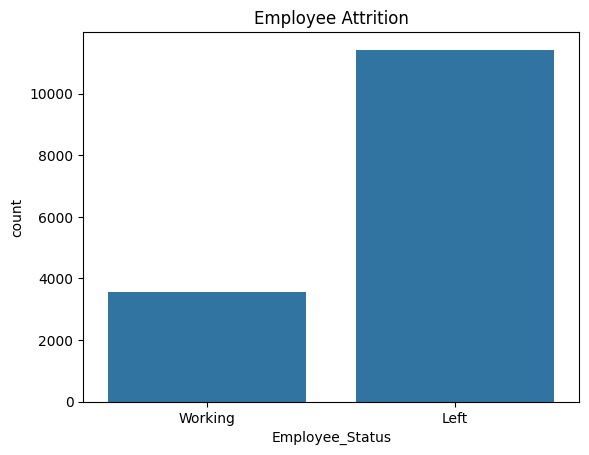

In [27]:
sns.countplot(x='Employee_Status', data=df)

plt.xticks([0,1], ['Working','Left'])

plt.title("Employee Attrition")
plt.show()

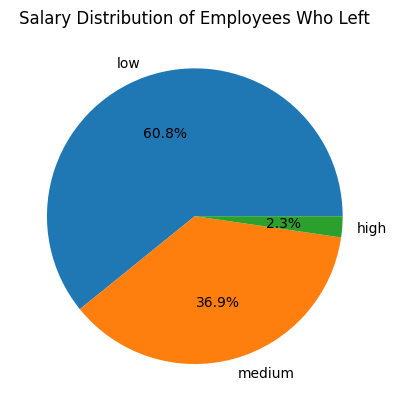

In [25]:
left_salary = df[df['Employee_Status'] == 'Left']['salary'].value_counts()
left_salary.plot(kind='pie'autopct='%1.1f%%')
plt.title('Salary Distribution of Employees Who Left')
plt.ylabel('')
plt.show()

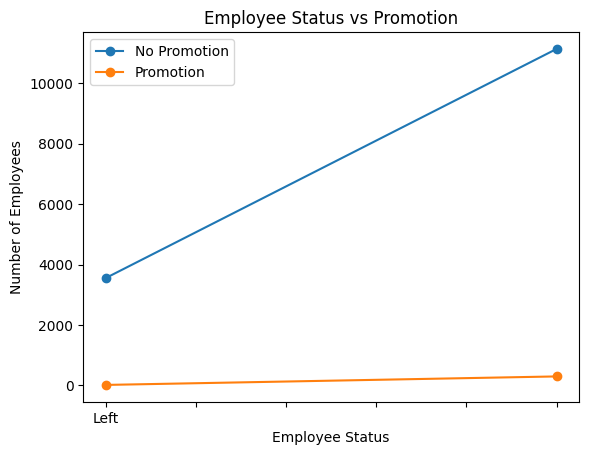

In [24]:
promotion = pd.crosstab(
    df['Employee_Status'],
    df['promotion_last_5years']
)

promotion.plot(
    kind='line',
    marker='o'
)

plt.title("Employee Status vs Promotion")
plt.xlabel("Employee Status")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.legend(['No Promotion', 'Promotion'])
plt.show()

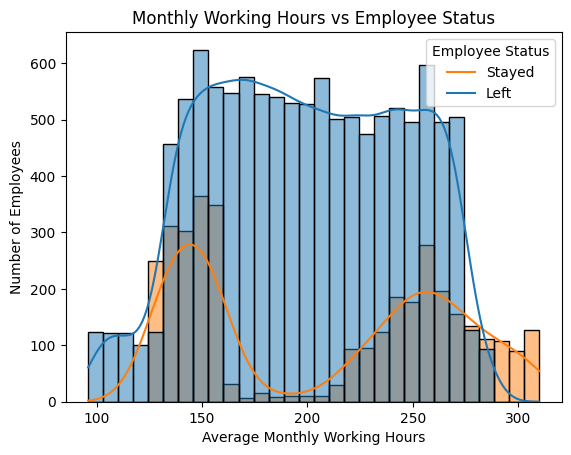

In [35]:
sns.histplot(
    data=df,
    x='average_montly_hours',
    hue='left',
    kde=True
)

plt.title("Monthly Working Hours vs Employee Status")
plt.xlabel("Average Monthly Working Hours")
plt.ylabel("Number of Employees")

plt.legend(title="Employee Status",
           labels=["Stayed", "Left"])

plt.show()

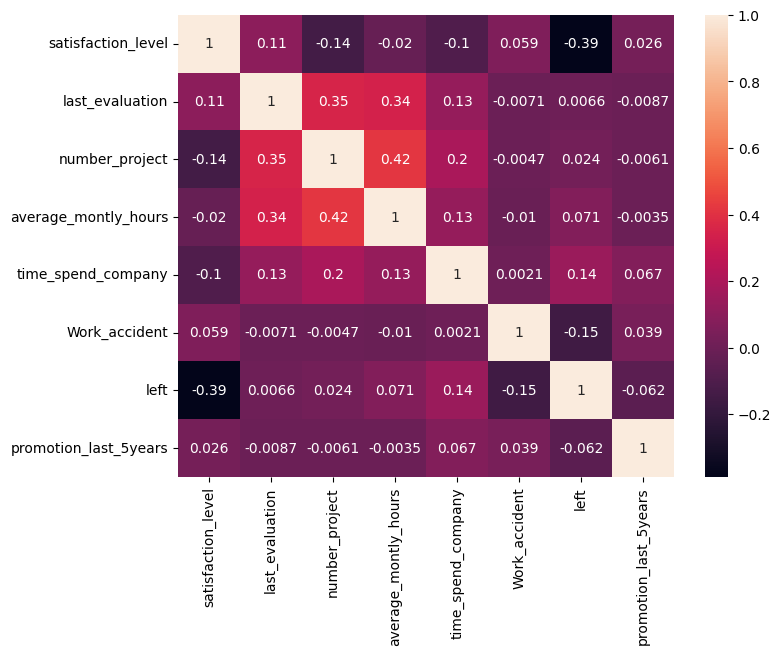

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True)

plt.show()

**INSIGHTS**
- Employees with lower satisfaction levels are more likely to leave the company.
- Employees receiving lower salaries show higher attrition rates.
- Employees working longer hours tend to leave the organization more frequently.
- A higher number of assigned projects may contribute to employee turnover.
- Lack of promotions negatively impacts employee retention.
- Certain departments experience higher attrition rates compared to others.
- These insights can help improve HR management practices and employee retention strategies.